In [1]:
#############################################
##### this is a test script for axolotl tracking 
##### modified based on the original code https://github.com/vivekhsridhar/tracktor/blob/master/examples/3g%20Zebrafish_schooling.ipynb
##### run_1 for all videos in Animal 15, 27, 34, 39
##### add the adaptive threshold searching using the upper quantile of image intensity
#############################################

In [2]:
import numpy as np
import pandas as pd
import tracktor as tr
import cv2
import sys
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import os
import math
from skimage.io import imread

## Global parameters
This cell (below) enlists user-defined parameters

In [3]:
# colours is a vector of BGR values which are used to identify individuals in the video
# since we only have one individual, the program will only use the first element from this array i.e. (0,0,255) - red
# number of elements in colours should be greater than n_inds (THIS IS NECESSARY FOR VISUALISATION ONLY)
n_inds = 1
#colours = [(255,0,0),(0,255,255),(255,0,255),(255,255,255),(255,255,0),(255,0,0),(0,255,0),(0,0,0)]
colours = [(0,0,255),(0,255,255),(255,0,255), (255,255,0),(255,0,0),(0,255,0)]


# this is the block_size and offset used for adaptive thresholding (block_size should always be odd)
# these values are critical for tracking performance
#block_size = 51
#offset = 20

# the scaling parameter can be used to speed up tracking if video resolution is too high (use value 0-1)
# not use fixed scaling, rather calculate the scaling_img to reduce the all images to 300*300
#scaling = 1.0 

# mot determines whether the tracker is being used in noisy conditions to track a single object or for multi-object
# using this will enable k-means clustering to force n_inds number of animals
mot = False

## parameters added for axolotl images
nb_skippedFrame = 700 # nb of frames to skip to make sure axolotl is there

#threshold_value = 120 # threshold used in the gray image to detect axolotl; 
threshold_quantile =  0.9975 #use the adpative thresholding searach


# minimum area and maximum area occupied by the animal in number of pixels
# this parameter is used to get rid of other objects in view that might be hard to threshold out but are differently sized
min_area = 100 
max_area = 800
min_circularity = 0.1 ## minimum circularity of object for detected animal

#### 
display_outFrame = True

In [12]:
# name of source video and paths
input_vidpath = '/Volumes/groups/tanaka/People/current/jiwang/projects/image_analysis/Deinz_axolot_tracking/run_1/A34/' # path to all video folders
output_dir = '/Users/jingkui.wang/workspace/imp/image_analysis_test/results/output_videoTracking_run1/A34/'
codec = 'DIVX' # try other codecs if the default doesn't work ('DIVX', 'avc1', 'XVID') note: this list is non-exhaustive

if not os.path.exists(output_dir):
    os.mkdir(output_dir)

In [13]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names), print(len(folder_names))

['A34_1wpt_1_D1', 'A34_1wpt_2_L1', 'A34_1wpt_3_D2', 'A34_1wpt_4_L2', 'A34_1wpt_5_L3', 'A34_1wpt_6_D3', 'A34_4wpt_1_L1', 'A34_4wpt_2_D1', 'A34_4wpt_3_D2', 'A34_4wpt_4_L2', 'A34_4wpt_5_D3', 'A34_4wpt_6_L3', 'A34_6wpt_1_D1', 'A34_6wpt_2_L1', 'A34_6wpt_3_L2', 'A34_6wpt_4_L3', 'A34_6wpt_5_D2', 'A34_6wpt_6_D3', 'A34_8wpt_1_L1', 'A34_8wpt_2_D1', 'A34_8wpt_3_D2', 'A34_8wpt_4_L2', 'A34_8wpt_5_D3', 'A34_8wpt_6_L3', 'A34_preONT_1_L1', 'A34_preONT_2_D1', 'A34_preONT_3_D2', 'A34_preONT_4_L2', 'A34_preONT_5_D3', 'A34_preONT_6_L3']
30


(None, None)

In [14]:
## test only specific video
#folder_names = folder_names[1]
#print(folder_names)
#if isinstance(folder_names, str):
#    folder_names = [folder_names]
#for folder in folder_names:
#    print(folder)

In [15]:
if isinstance(folder_names, str):
    folder_names = [folder_names]
    
for folder in folder_names:
    
    ## Start time
    start = time.time()
    
    print(folder)
    
    video = folder
    output_vidpath = output_dir + video + '.mp4'
    output_filepath = output_dir + video + '.csv'
    output_figpath = output_dir + video + '.pdf'
    output_error = output_dir + video + '_error.csv'
    output_circle = output_dir + video + '_circle.csv'
    
    video_path = Path(input_vidpath + folder + '/')
    first_file = next(p.name for p in video_path.iterdir() if p.is_file())
    #files = [p for p in video_path.iterdir() if p.is_file()]
    #first_file = files[0].name
    file_name = Path(first_file).stem
    #print(file_name)
    file_split = file_name.split("_")
    f_newname = "_".join(file_split[:-1])
    
    print(f_newname)
    #'1_D1_test/Basler_acA2040-120um__24899445__20260407_140424600_%04d.tiff'
    
    ##########
    # check first the shape of image to determine the scaling parameter
    ##########
    img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
    scaling_img = 300/img.shape[0]
    
    del img
    
    ###################################################
    ### loop over videos
    ###################################################
    ## Open video
    cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')
    
    if cap.isOpened() == False:
        sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

    ## Video writer class to output video with contour and centroid of tracked object(s)
    # make sure the frame size matches size of array 'final'
    fourcc = cv2.VideoWriter_fourcc(*codec)
    output_framesize = (int(cap.read()[1].shape[1]*scaling_img),int(cap.read()[1].shape[0]*scaling_img))
    out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

    ## Individual location(s) measured in the last and current step
    meas_last = list(np.zeros((n_inds,2)))
    meas_now = list(np.zeros((n_inds,2)))
    
    last = 0
    df = []
    err = []
    
    ## first frame to detect the coordinate and radius of circles
    #cap.set(1,1)
    ## strat the tracing from the frame 500 to skip those without axolotl
    cap.set(1, nb_skippedFrame)
    
    ret, frame = cap.read()
    
    frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur_frame = cv2.medianBlur(gray_frame, 5)
    
    ## to adapt different number of piexls in the videos
    #minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
    #maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))
    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = minRadius_circle, maxRadius = maxRadius_circle)

    #circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 10, minRadius = 120, maxRadius = 150)
    circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
    circles = np.uint8(np.around(circles))
    
    print(circles)
    
    if len(circles) == 1:
        circle_run = circles[0,:][0]
        
        circle_x = circle_run[0]
        circle_y = circle_run[1]
        #circle_radius = circle_run[2] - 2
        circle_radius = 130
        
        circle_position = [circle_x, circle_y, circle_radius]
        
        circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
        circle_position.to_csv(output_circle, sep=',')
        
    else:
        print('zero or > 1 circles found ')
        break
    
    
    while(True):
        # Capture frame-by-frame
        ret, frame = cap.read()
        
        this = cap.get(1)
    
        if ret == True:
            frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
        
            # Apply mask to the area of interest
            mask = np.zeros(frame.shape)
            #mask = cv2.circle(mask, (308, 235), 215, (255,255,255), -1)
            #mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
            mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
            
            #frame[mask ==  0] = np.median(frame[mask >  0])
            frame[mask ==  0] = 0
        
            blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur = cv2.medianBlur(blur, 5)
            
            threshold_value = np.quantile(blur.ravel(), threshold_quantile)
            
            _, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
            #thresh = tr.colour_to_thresh(frame, block_size, offset)
            thresh = binary
            final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, 
                                                                               min_circularity = 0.1)
            
            try:
                row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
                final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
            except:
                #print(this,  "frame Error")
                err.append([f_newname, this])
                
                continue
            
            # Create output dataframe
            for i in range(n_inds):
                df.append([this, meas_now[i][0], meas_now[i][1]])
        
            # Display the resulting frame
            out.write(final)
            cv2.imshow('frame', final)
            if cv2.waitKey(1) == 27:
                break
            #if display_outFrame:
               
            
        if last == this:
            break
    
        last = this
    
    ## Write positions to file
    df = pd.DataFrame(np.matrix(df), columns = ['frame','pos_x','pos_y'])
    df.to_csv(output_filepath, sep=',')

    if len(err) > 0:
        err = pd.DataFrame(np.matrix(err), columns = ['video','frame'])
        err.to_csv(output_error, sep=',')
    
    ## When everything done, release the capture
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

    ####################################
    # Plot tracks
    # The code below allows you to see individual tracks. By counting the number of jumps in the tracks, one can identify number of false detections.
    ####################################
    df = pd.read_csv(output_filepath)
    
    
    plt.figure(figsize=(8, 8))
    plt.scatter(df['pos_x'], df['pos_y'], c=df['frame'])
    plt.xlabel('pos_x')
    plt.ylabel('pos_y')
    plt.savefig(output_figpath, format = 'pdf', bbox_inches="tight")
    plt.close()

    ## End time and duration
    end = time.time()
    duration = (end - start)/60
    
    print("--- %s minutes ---" %duration)
    

A34_1wpt_1_D1
Basler_acA2040-120um__24899445__20260407_140424600


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[[[148 154 132]]]
--- 29.92224151690801 minutes ---
A34_1wpt_2_L1
Basler_acA2040-120um__24899445__20260407_144747890


OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[[[156 140 132]]]
837.0 frame Error
838.0 frame Error


...

OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[[[152 152 138]]]
702.0 frame Error
703.0 frame Error
704.0 frame Error
705.0 frame Error
706.0 frame Error
707.0 frame Error
708.0 frame Error
709.0 frame Error
710.0 frame Error
711.0 frame Error
712.0 frame Error
713.0 frame Error
714.0 frame Error
715.0 frame Error
716.0 frame Error
717.0 frame Error
718.0 frame Error
719.0 frame Error
720.0 frame Error
721.0 frame Error
722.0 frame Error
723.0 frame Error
724.0 frame Error
725.0 frame Error
726.0 frame Error
727.0 frame Error
728.0 frame Error
729.0 frame Error
730.0 frame Error
731.0 frame Error
732.0 frame Error
733.0 frame Error
734.0 frame Error
735.0 frame Error
736.0 frame Error
737.0 frame Error
738.0 frame Error
739.0 frame Error
740.0 frame Error
741.0 frame Error
742.0 frame Error
743.0 frame Error
744.0 frame Error
745.0 frame Error
746.0 frame Error
747.0 frame Error
748.0 frame Error
749.0 frame Error
750.0 frame Error
751.0 frame Error
752.0 frame Error
753.0 frame Error
754.0 frame Error
755.0 frame Error
756.0 fram

OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


[[[152 152 138]]]
711.0 frame Error
712.0 frame Error
716.0 frame Error
717.0 frame Error
718.0 frame Error
719.0 frame Error
720.0 frame Error
721.0 frame Error
722.0 frame Error
723.0 frame Error
724.0 frame Error
725.0 frame Error
726.0 frame Error
727.0 frame Error
728.0 frame Error
729.0 frame Error
730.0 frame Error
731.0 frame Error
732.0 frame Error
734.0 frame Error
735.0 frame Error
736.0 frame Error
737.0 frame Error
738.0 frame Error
741.0 frame Error
742.0 frame Error
745.0 frame Error
746.0 frame Error
748.0 frame Error
749.0 frame Error
750.0 frame Error
753.0 frame Error
754.0 frame Error
755.0 frame Error
756.0 frame Error
757.0 frame Error
758.0 frame Error
759.0 frame Error
760.0 frame Error
764.0 frame Error
765.0 frame Error
770.0 frame Error
771.0 frame Error
775.0 frame Error
776.0 frame Error
777.0 frame Error
778.0 frame Error
779.0 frame Error
788.0 frame Error
789.0 frame Error
790.0 frame Error
791.0 frame Error
792.0 frame Error
793.0 frame Error
794.0 fram

KeyboardInterrupt: 

In [ ]:
###########################################################
###########################################################
## debug specific folder or file
###########################################################
###########################################################

In [90]:
from pathlib import Path
directory = Path(input_vidpath)

folder_names = [p.name for p in directory.iterdir() if p.is_dir()]
print(folder_names)

['A15_1wpt_1_D1', 'A15_1wpt_2_L1', 'A15_1wpt_3_D2', 'A15_1wpt_4_D3', 'A15_1wpt_5_L2', 'A15_1wpt_6_L3', 'A15_4wpt_1_L1', 'A15_4wpt_2_D1', 'A15_4wpt_3_L2', 'A15_4wpt_4_D2', 'A15_4wpt_5_L3', 'A15_4wpt_6_D3', 'A15_6wpt_1_D1', 'A15_6wpt_2_L1', 'A15_6wpt_3_L2', 'A15_6wpt_4_D2', 'A15_6wpt_5_L3', 'A15_6wpt_6_D3', 'A15_8wpt_1_L1', 'A15_8wpt_2_D1', 'A15_8wpt_3_D2', 'A15_8wpt_4_D3', 'A15_8wpt_5_L2', 'A15_8wpt_6_L3', 'A15_preONT_1_D1', 'A15_preONT_2_L1', 'A15_preONT_3_L2', 'A15_preONT_4_D2', 'A15_preONT_5_L3', 'A15_preONT_6_D3', 'A27_1wpt_1_D1', 'A27_1wpt_2_D2', 'A27_1wpt_3_L1', 'A27_1wpt_4_L2', 'A27_1wpt_5_L3', 'A27_1wpt_6_D3', 'A27_4wpt_1_D1', 'A27_4wpt_2_L1', 'A27_4wpt_3_D2', 'A27_6wpt_1_L1', 'A27_4wpt_4_L2', 'A27_4wpt_5_L3', 'A27_4wpt_6_D3', 'A27_6wpt_2_L2', 'A27_6wpt_3_D1', 'A27_6wpt_4_D2', 'A27_6wpt_5_L3', 'A27_6wpt_6_D3', 'A27_8wpt_1_D1', 'A27_8wpt_2_L1', 'A27_8wpt_3_L2', 'A27_8wpt_4_D2', 'A27_8wpt_5_L3', 'A27_8wpt_6_D3', 'A27_preONT_1_L1', 'A27_preONT_2_L2', 'A27_preONT_3_L3', 'A27_preONT_

In [91]:
## test only specific video
folder_names = folder_names[61]
#print(folder_names)
if isinstance(folder_names, str):
    folder_names = [folder_names]
for folder in folder_names:
    print(folder)

A34_preONT_1_L1


In [151]:
folder = 'A34_1wpt_3_D2'
folder = 'A15_1wpt_1_D1'
folder = 'A34_1wpt_2_L1'

In [152]:
#print(scaling_img)

In [153]:
input_vidpath
video = folder
output_vidpath = output_dir + video + '.mp4'
output_filepath = output_dir + video + '.csv'
output_figpath = output_dir + video + '.pdf'
output_error = output_dir + video + '_error.csv'

In [154]:
video_path = Path(input_vidpath + folder + '/')
first_file = next(p.name for p in video_path.iterdir() if p.is_file())
#files = [p for p in video_path.iterdir() if p.is_file()]
#first_file = files[0].name
file_name = Path(first_file).stem
#print(file_name)
file_split = file_name.split("_")
f_newname = "_".join(file_split[:-1])
    
print(f_newname)

##########
# check first the shape of image to determine the scaling parameter
##########
img = imread(input_vidpath + '/' + folder + '/' + f_newname + '_0000.tiff')
scaling_img = 300/img.shape[0]
    
del img
print(scaling_img)

Basler_acA2040-120um__24899445__20260407_144747890
1.0


In [155]:
cap = cv2.VideoCapture(input_vidpath + '/' + folder + '/' + f_newname + '_%04d.tiff')

if cap.isOpened() == False:
    sys.exit('Video file cannot be read! Please check input_vidpath to ensure it is correctly pointing to the video file')

## Video writer class to output video with contour and centroid of tracked object(s)
# make sure the frame size matches size of array 'final'
fourcc = cv2.VideoWriter_fourcc(*codec)
output_framesize = (int(cap.read()[1].shape[1]*scaling_img),int(cap.read()[1].shape[0]*scaling_img))
out = cv2.VideoWriter(filename = output_vidpath, fourcc = fourcc, fps = 30.0, frameSize = output_framesize, isColor = True)

## Individual location(s) measured in the last and current step
meas_last = list(np.zeros((n_inds,2)))
meas_now = list(np.zeros((n_inds,2)))

last = 0
df = []

OpenCV: FFMPEG: tag 0x58564944/'DIVX' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


In [175]:
cap.set(1,700)
threshold_value = 120
ret, frame = cap.read()
frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)

In [176]:
this = cap.get(1)

In [177]:
gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur_frame = cv2.medianBlur(gray_frame, 5)
print(blur_frame.shape)

import math

#minRadius_circle = math.floor(120 * (blur_frame.shape[1]/300))
#maxRadius_circle = math.floor(140 * (blur_frame.shape[1]/300))


circles = cv2.HoughCircles(blur_frame, cv2.HOUGH_GRADIENT, 1, 50, minRadius = 120, maxRadius = 140)
#circles = np.uint8(np.around(circles))

print(circles)

circles = np.uint8(np.around(circles))
    
if len(circles) == 1:
    circle_run = circles[0,:][0]
        
    circle_x = circle_run[0]
    circle_y = circle_run[1]
    #circle_radius = circle_run[2] - 2
    circle_radius = 130
        
    circle_position = [circle_x, circle_y, circle_radius]
        
    #circle_position = pd.DataFrame(np.matrix(circle_position), columns = ['x','y','radius'])
    #circle_position.to_csv(output_circle, sep=',')
print(circles)

(300, 300)
[[[155.5 140.5 132.3]]]
[[[156 140 132]]]


In [178]:
np.around(circles)

array([[[156, 140, 132]]], dtype=uint8)

In [179]:
#cap.set(1, nb_skippedFrame)

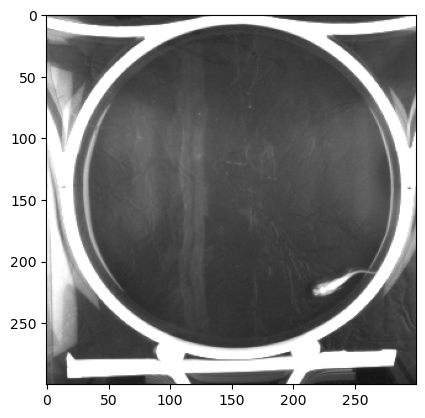

In [180]:
#ret, frame = cap.read()
#frame = cv2.resize(frame, None, fx = scaling_img, fy = scaling_img, interpolation = cv2.INTER_LINEAR)
plt.imshow(frame,'gray')

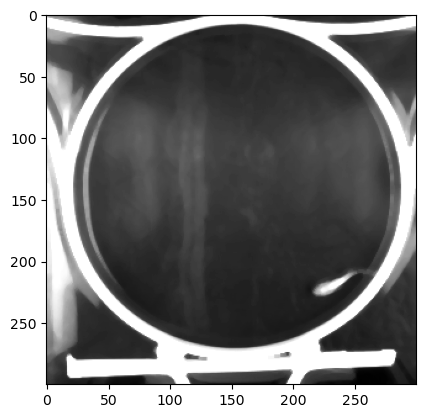

In [181]:
plt.imshow(blur_frame,'gray')

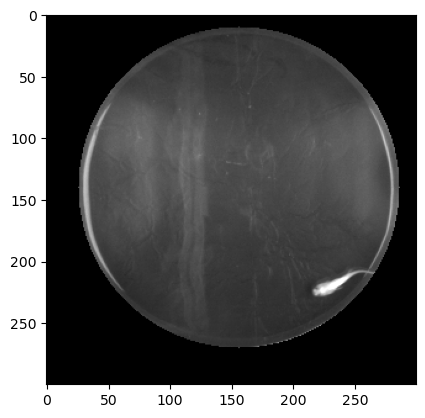

In [182]:
# Apply mask to the area of interest
mask = np.zeros(frame.shape)
#mask = cv2.circle(mask, (147, 155), 130, (255,255,255), -1)
mask = cv2.circle(mask, (circle_x, circle_y), circle_radius, (255,255,255), -1)
frame[mask ==  0] = 0
plt.imshow(frame,'gray')

In [183]:
blur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
blur = cv2.medianBlur(blur, 5)

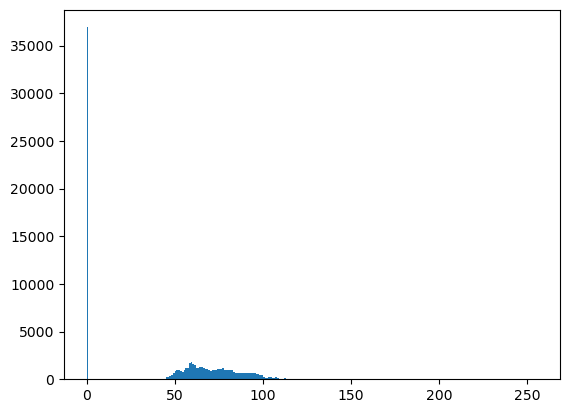

In [184]:
plt.hist(blur.ravel(), bins=256, range=(0, 256))
plt.show()

In [185]:
from scipy.stats import percentileofscore
print(percentileofscore(blur.ravel(), 120))
a = blur.ravel()
len(a)
blur.shape

99.07


(300, 300)

In [186]:
print((blur.ravel() > 120).sum())
print(1-(blur.ravel() > 120).sum()/300/300)

818
0.9909111111111111


In [187]:
print(np.quantile(blur.ravel(), 0.9975))

170.0


In [188]:
threshold_value = np.quantile(blur.ravel(), 0.9975)
print((blur.ravel() > threshold_value).sum())

224


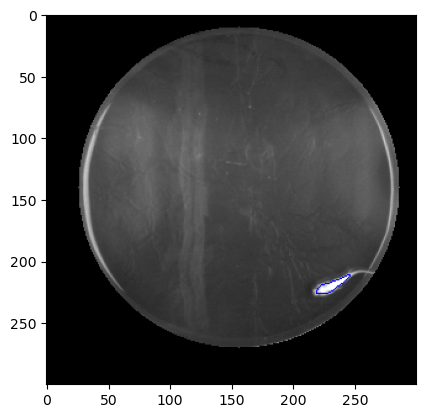

In [189]:
_, binary = cv2.threshold(blur, threshold_value, 255, cv2.THRESH_BINARY)
#thresh = tr.colour_to_thresh(frame, block_size, offset)
thresh = binary
final, contours, meas_last, meas_now = tr.detect_and_draw_contours(frame, thresh, meas_last, meas_now, min_area, max_area, min_circularity = 0.1)
plt.imshow(final,'gray')

In [190]:
print(min_area, max_area)

100 800


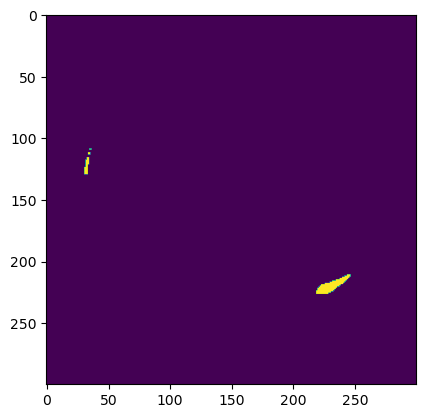

In [191]:
plt.imshow(binary)

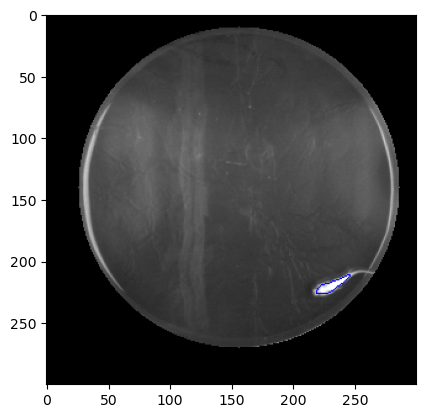

In [192]:
plt.imshow(final)

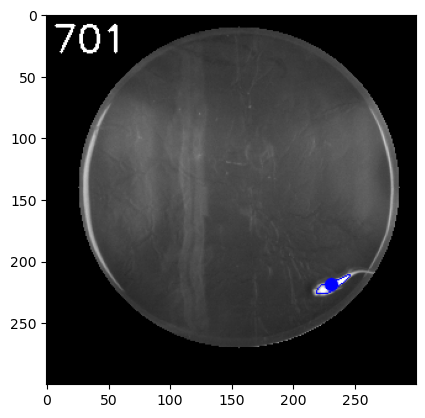

In [193]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)
plt.imshow(final,'gray')

In [27]:
threshold_value = 115
threshold_value_adaptive = np.percentile(blur, 99.)
threshold_value_adaptive, threshold_value

(np.float64(115.0), 115)

In [30]:
300*300*0.22/100

198.0

(100, 800)

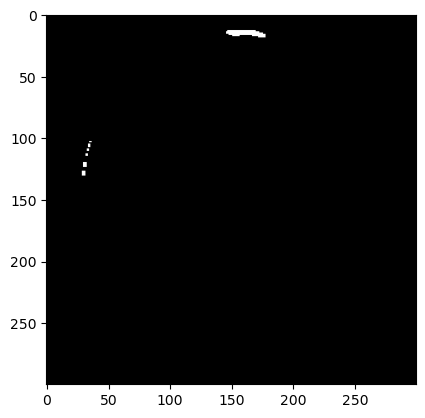

In [29]:
plt.imshow(binary,'gray')
min_area, max_area

In [ ]:
row_ind, col_ind = tr.hungarian_algorithm(meas_last, meas_now)
        final, meas_now, df = tr.reorder_and_draw(final, colours, n_inds, col_ind, meas_now, df, mot, this)